In [10]:
#import libraries
import pandas as pd
import re
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
#make sure to download data as vaccine_tweets.csv or rename data file
df = pd.read_csv("vaccine_tweets.csv")


df.head()

,tweet_id,label,tweet_text
0,1.360342e+18,1,"4,000 a day dying from the so called covid-19 ..."
1,1.382896e+18,2,pranam message for today manifested in dhyan b...
2,1.375673e+18,2,hyderabad-based ?? has sought funds from the g...
3,1.381311e+18,1,"confirmation that chinese vaccines ""dont have..."
4,1.362166e+18,3,"lab studies suggest pfizer, moderna vaccines c..."


In [12]:
#clean data
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    return text

df["clean_text"] = df["tweet_text"].apply(clean_text)

In [13]:
#define different themes
themes = {
    "safety": ["side effect", "safe", "risk", "blood clot", "paralysis", "fatigue"],
    "misinformation": ["hoax", "fake", "microchip", "scam", "not useful"],
    "access": ["appointment", "dose", "available", "get vaccinated", "first dose"],
}

def assign_theme(text):
    for theme, words in themes.items():
        for word in words:
            if word in text:
                return theme
    return "general"

df["theme"] = df["clean_text"].apply(assign_theme)

df[["tweet_text", "theme"]].head()

,tweet_text,theme
0,"4,000 a day dying from the so called covid-19 ...",general
1,pranam message for today manifested in dhyan b...,general
2,hyderabad-based ?? has sought funds from the g...,general
3,"confirmation that chinese vaccines ""dont have...",misinformation
4,"lab studies suggest pfizer, moderna vaccines c...",general


In [14]:
#use readable labels
label_map = {
    1: "negative",
    2: "neutral",
    3: "positive"
}

df["human_sentiment"] = df["label"].map(label_map)

df[["tweet_text", "human_sentiment"]].head()

,tweet_text,human_sentiment
0,"4,000 a day dying from the so called covid-19 ...",negative
1,pranam message for today manifested in dhyan b...,neutral
2,hyderabad-based ?? has sought funds from the g...,neutral
3,"confirmation that chinese vaccines ""dont have...",negative
4,"lab studies suggest pfizer, moderna vaccines c...",positive


In [15]:
#vader score and sentiment
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    return analyzer.polarity_scores(text)["compound"]

def vader_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_score"] = df["clean_text"].apply(vader_score)
df["vader_sentiment"] = df["vader_score"].apply(vader_label)

df[["tweet_text", "vader_score", "vader_sentiment"]].head()

,tweet_text,vader_score,vader_sentiment
0,"4,000 a day dying from the so called covid-19 ...",0.0000,neutral
1,pranam message for today manifested in dhyan b...,0.8156,positive
2,hyderabad-based ?? has sought funds from the g...,0.0000,neutral
3,"confirmation that chinese vaccines ""dont have...",-0.5432,negative
4,"lab studies suggest pfizer, moderna vaccines c...",0.3818,positive


In [16]:
#compare by theme
theme_sentiment = df.groupby("theme")["vader_score"].mean()
print(theme_sentiment)

pd.crosstab(df["theme"], df["human_sentiment"])

theme
access            0.164687
general           0.122800
misinformation   -0.215720
safety            0.168859
Name: vader_score, dtype: float64


human_sentiment,negative,neutral,positive
theme,,,
access,45,644,406
general,289,2768,1269
misinformation,5,43,8
safety,81,225,217


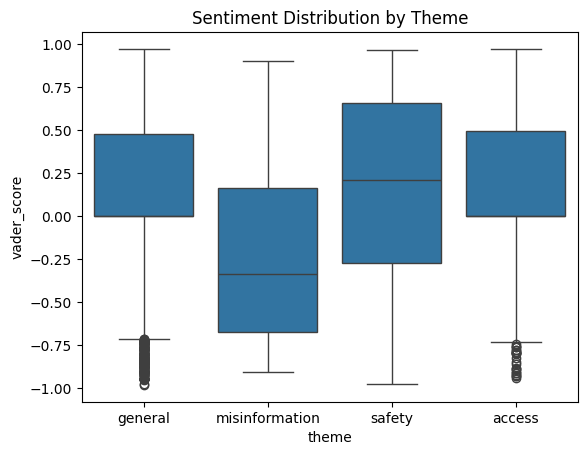

In [17]:
#graph
sns.boxplot(x="theme", y="vader_score", data=df)
plt.title("Sentiment Distribution by Theme")
plt.show()

In [18]:

mismatch = df[df["human_sentiment"] != df["vader_sentiment"]]

mismatch[["tweet_text", "human_sentiment", "vader_sentiment"]].head(10)

,tweet_text,human_sentiment,vader_sentiment
0,"4,000 a day dying from the so called covid-19 ...",negative,neutral
1,pranam message for today manifested in dhyan b...,neutral,positive
9,the day after the moderna covid19vaccine... my...,neutral,negative
10,not a girl but part of the moderna club ?,positive,neutral
17,embarrassing crimea russia everything is open ...,positive,negative
21,got the pfizerbiontech vaccine !!,positive,neutral
22,abusing atmanirbhar bharat as a political tool...,neutral,positive
27,just got my 2nd moderna shot. my mom &amp; gra...,positive,negative
28,especially because we lack data on johnsonandj...,neutral,negative
29,it happened!!!! covidvaccine pfizerbiontech ig...,positive,neutral


In [19]:

print("Average Sentiment by Theme:")
print(theme_sentiment)

print("\nTheme Counts:")
print(df["theme"].value_counts())

Average Sentiment by Theme:
theme
access            0.164687
general           0.122800
misinformation   -0.215720
safety            0.168859
Name: vader_score, dtype: float64

Theme Counts:
theme
general           4326
access            1095
safety             523
misinformation      56
Name: count, dtype: int64
